In [11]:
import pandas as pd

In [12]:
air=pd.read_csv("air_quality.csv")

In [13]:
heart=pd.read_csv("heart.csv")

In [30]:
air=air.dropna()

In [31]:
heart=heart.dropna()

In [32]:
print(air.head())

  Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;
0                                             7578;;                                                                          
1                                             7502;;                                                                          
2                                             7867;;                                                                          
3                                             7888;;                                                                          
4                                             7848;;                                                                          


In [33]:
print(heart.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [37]:
if isinstance(air.columns, pd.MultiIndex):
 air.columns=air.columns.get_level_values(0)

if isinstance(heart.columns,pd.MultiIndex):
 heart.columns=heart.columns.get_level_values(0)

air=air.reset_index(drop=True)
heart=heart.reset_index(drop=True)

data=pd.concat([air,heart],axis=1)

print(data)

     Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;  \
0                                                7578;;                                                                             
1                                                7502;;                                                                             
2                                                7867;;                                                                             
3                                                7888;;                                                                             
4                                                7848;;                                                                             
...                                                 ...                                                                             
6910                                             7568;;              

In [40]:
data = data[data["age"] <= 100]



In [49]:
data["age"] = pd.to_numeric(data["age"], errors='coerce')
data["trestbps"] = pd.to_numeric(data["trestbps"], errors='coerce')
data["chol"] = pd.to_numeric(data["chol"], errors='coerce')
data = data.dropna()

In [50]:
from sklearn.linear_model import LogisticRegression

x=data[["age","chol","trestbps"]]
y=data["target"]


model=LogisticRegression();
model.fit(x,y)
print("Model Trained Successfully")


import pandas as pd
test = pd.DataFrame([[25,200,120]], columns=["age","chol","trestbps"])

pred = model.predict(test)
print(pred)

if pred[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Model Trained Successfully
[1.]
Heart Disease Detected


In [51]:
import matplotlib.pyplot as plt

In [56]:
import seaborn as sns
import numpy as np

In [57]:
corr=data.select_dtypes(include=np.number).corr()

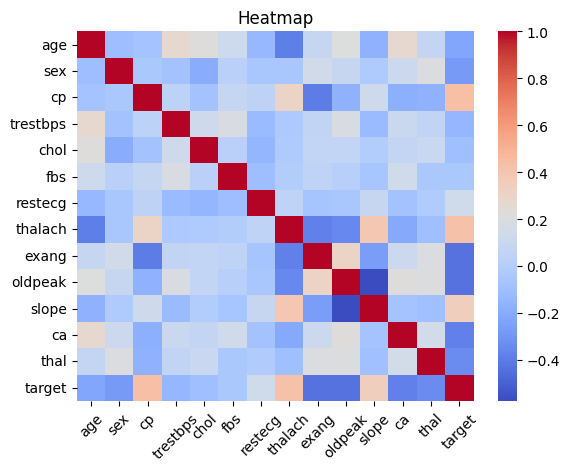

In [63]:
sns.heatmap(corr,cmap="coolwarm")
plt.title("Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'xtricks'

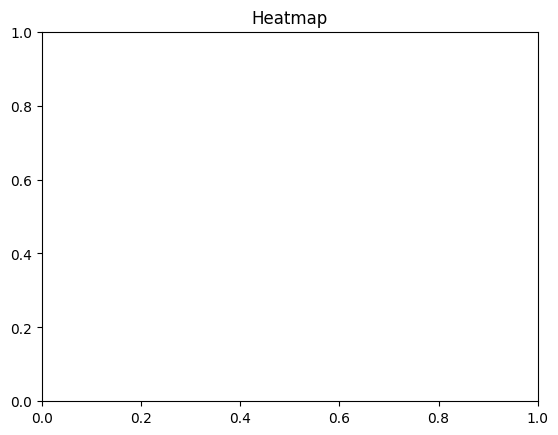